# GWPbio Carbon Sequestration Module
### RAW Project — 3D-Printed Biopolymer LCA

This notebook computes the **biogenic carbon sequestration credit** for a
3D-printed biopolymer panel, following the GWP_bio method of:

> Guest, G., Cherubini, F., & Strømman, A. H. (2012). Global warming potential
> of carbon dioxide emissions from biomass stored in the anthroposphere and used
> for bioenergy at end of life. *Journal of Industrial Ecology*, 16(8), 1–11.
> https://doi.org/10.1111/j.1530-9290.2012.00507.x

#### Logic in brief
1. Read the current biopolymer recipe from the Brightway `3D printing` node.
2. Look up the GWP_bio characterisation factor for each sequestration-eligible
   ingredient from Guest et al. Table 1 (100-year time horizon), interpolating
   linearly for product lifetimes that fall between table columns.
3. Multiply ingredient amount × carbon fraction × (44/12) × GWP_bio to obtain
   **kg CO₂eq sequestered per kg of final panel**.

A **negative result** = sequestration credit (climate benefit).  
A **positive result** = net emission (climate burden).

This is fully consistent with standard LCA sign conventions (EN 15804, ecoinvent).

---
#### Brightway environment
- Conda env: `bw2`
- Project: `biopol_lca`
- Foreground database: `lca_database_3DPrintedBiopol`


## 1 · Brightway setup

In [1]:
import bw2data as bd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import random

bd.projects.set_current('biopol_lca')
print("Active project:", bd.projects.current)
print("Databases:", list(bd.databases))


Active project: biopol_lca
Databases: ['lca_database_3DPrintedBiopol', 'biosphere-3.12', 'ecoinvent-3.12-cutoff']


In [2]:
DB_NAME = 'lca_database_3DPrintedBiopol'
db = bd.Database(DB_NAME)

node_printing = bd.get_node(name='3D printing', database=DB_NAME)
print("Found node:", node_printing['name'])
print("\nAll technosphere exchanges:")
for exc in node_printing.technosphere():
    print(f"  {exc.input['name']:45s}  amount = {exc['amount']:.6f}")


Found node: 3D printing

All technosphere exchanges:
  market for electricity, medium voltage         amount = 0.117647
  industrial machine production, heavy, unspecified  amount = 0.001343
  hemp dust filler production                    amount = 0.300000
  pea protein binder production                  amount = 0.500000
  seagrass filler production                     amount = 0.200000
  market for glycerine                           amount = 0.000000
  market for calcium chloride                    amount = 0.000000
  bark flour filler production                   amount = 1.000000
  wood flour filler production                   amount = 1.000000
  cotton filler production                       amount = 1.000000
  cellulose filler production                    amount = 1.000000


## 2 · Recipe configuration

The biopolymer recipe is defined by technosphere exchanges on the `3D printing`
node.  Each run of this section:

1. Randomly selects **0, 1, or 2 fillers** from the six available fillers.
2. Assigns fractions that sum **exactly to 1.0**, with pea protein binder ≥ 0.7.
3. Sets all unused filler amounts to **0.0** (overwriting the dummy value of 1.0
   that is currently stored in Brightway for all fillers).
4. Writes the new fractions back to Brightway.

> ⚠️ **Note:** The minimum pea protein fraction is set to 0.70.  
> Verify this constraint with the material science team once formulation targets
> are finalised.


In [46]:
# ── Helper ────────────────────────────────────────────────────────────────────
def set_exchange_amount(node, producer_name: str, amount: float) -> None:
    """Update the amount of a technosphere exchange identified by producer name."""
    matches = [e for e in node.technosphere() if producer_name in e.input['name']]
    if not matches:
        raise ValueError(f"No exchange found with producer name containing '{producer_name}'")
    edge = matches[0]
    edge['amount'] = amount
    edge.save()

# ── Filler registry ───────────────────────────────────────────────────────────
# All six fillers that appear as exchanges on the 3D printing node.
ALL_FILLERS = [
    'hemp dust filler production',
    'bark flour filler production',
    'wood flour filler production',
    'seagrass filler production',
    'cotton filler production',
    'cellulose filler production',
]

BINDER = 'pea protein binder production'
BINDER_MIN = 0.70  # minimum fraction for pea protein binder — verify with formulation team

# ── Random recipe generator ───────────────────────────────────────────────────
random.seed()  # set seed for reproducibility; change or remove for random behaviour

n_fillers = random.randint(0, 2)                         # 0, 1, or 2 fillers
chosen_fillers = random.sample(ALL_FILLERS, n_fillers)

# Assign binder fraction >= BINDER_MIN; remainder split among chosen fillers
binder_fraction = round(random.uniform(BINDER_MIN, 1.0), 2)
remainder = round(1.0 - binder_fraction, 4)

if n_fillers == 0:
    binder_fraction = 1.0
    filler_fractions = {}
elif n_fillers == 1:
    filler_fractions = {chosen_fillers[0]: remainder}
else:
    # split remainder between two fillers at a random cut point
    cut = round(random.uniform(0.0, 1.0), 2)
    filler_fractions = {
        chosen_fillers[0]: round(remainder * cut, 2),
        chosen_fillers[1]: round(remainder * (1.0 - cut), 2),
    }

# Ensure exact sum = 1.0 by correcting floating-point rounding on the binder
total = binder_fraction + sum(filler_fractions.values())
binder_fraction = round(binder_fraction + (1.0 - total), 2)

recipe = {BINDER: binder_fraction, **filler_fractions}

print("Generated recipe:")
for name, frac in recipe.items():
    print(f"  {name:45s}  {frac:.2f}")
print(f"  {'TOTAL':45s}  {sum(recipe.values()):.2f}")


Generated recipe:
  pea protein binder production                  0.72
  seagrass filler production                     0.06
  hemp dust filler production                    0.22
  TOTAL                                          1.00


In [48]:
# ── Write recipe to Brightway ─────────────────────────────────────────────────

# Step 1: zero out ALL fillers (including unused ones with dummy amount=1.0)
for filler_name in ALL_FILLERS:
    set_exchange_amount(node_printing, filler_name, 0.0)

# Step 2: set binder
set_exchange_amount(node_printing, BINDER, recipe[BINDER])

# Step 3: set chosen fillers
for filler_name, frac in filler_fractions.items():
    set_exchange_amount(node_printing, filler_name, frac)

# Step 4: verify
print("Verified exchanges after writing:")
for exc in node_printing.technosphere():
    if exc.input['name'] in [BINDER] + ALL_FILLERS:
        print(f"  {exc.input['name']:45s}  amount = {exc['amount']:.2f}")


Verified exchanges after writing:
  hemp dust filler production                    amount = 0.22
  pea protein binder production                  amount = 0.72
  seagrass filler production                     amount = 0.06
  bark flour filler production                   amount = 0.00
  wood flour filler production                   amount = 0.00
  cotton filler production                       amount = 0.00
  cellulose filler production                    amount = 0.00


## 3 · GWP_bio lookup table

Hardcoded from **Guest et al. (2012), Table 1** — 100-year time horizon.

Rows = rotation period (years): 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100  
Columns = storage period / product lifetime (years): 0, 10, 20, …, 100

For product lifetimes that do not fall on a 10-year interval, the factor is
obtained by **linear interpolation** between the two nearest columns.

Sign convention (Guest et al.):
- **Negative GWP_bio** → sequestration credit (climate benefit)
- **Positive GWP_bio** → net emission (climate burden)


In [26]:
# ── Guest et al. (2012) Table 1 — 100-year time horizon ──────────────────────
# Rows: rotation periods (years)
# Columns: storage periods 0, 10, 20, ..., 100 years

ROTATION_PERIODS = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
STORAGE_PERIODS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

GWPBIO_TABLE = {
  #  rot:  [  0,     10,    20,    30,    40,    50,    60,    70,    80,    90,   100]
     1:    [ 0.00, -0.07, -0.15, -0.23, -0.32, -0.40, -0.50, -0.60, -0.71, -0.84, -0.99],
    10:    [ 0.04, -0.04, -0.12, -0.20, -0.28, -0.37, -0.46, -0.57, -0.68, -0.80, -0.96],
    20:    [ 0.08,  0.00, -0.08, -0.16, -0.24, -0.33, -0.42, -0.53, -0.64, -0.76, -0.92],
    30:    [ 0.12,  0.04, -0.04, -0.12, -0.20, -0.29, -0.38, -0.48, -0.60, -0.72, -0.88],
    40:    [ 0.16,  0.09,  0.01, -0.08, -0.16, -0.25, -0.34, -0.44, -0.55, -0.68, -0.84],
    50:    [ 0.20,  0.13,  0.05, -0.03, -0.12, -0.21, -0.30, -0.40, -0.51, -0.64, -0.80],
    60:    [ 0.25,  0.17,  0.09,  0.01, -0.07, -0.16, -0.26, -0.36, -0.47, -0.59, -0.75],
    70:    [ 0.29,  0.22,  0.14,  0.06, -0.03, -0.12, -0.21, -0.31, -0.42, -0.55, -0.71],
    80:    [ 0.34,  0.26,  0.18,  0.10,  0.02, -0.07, -0.17, -0.27, -0.38, -0.50, -0.66],
    90:    [ 0.38,  0.31,  0.23,  0.15,  0.06, -0.03, -0.12, -0.22, -0.33, -0.46, -0.62],
   100:    [ 0.44,  0.37,  0.29,  0.21,  0.12,  0.032,-0.06, -0.16, -0.27, -0.40, -0.56],
}

# Convert to a DataFrame for inspection
gwpbio_df = pd.DataFrame(
    GWPBIO_TABLE,
    index=STORAGE_PERIODS
).T
gwpbio_df.index.name   = 'Rotation period (yr)'
gwpbio_df.columns.name = 'Storage period (yr)'
print("GWP_bio lookup table (Guest et al. 2012, Table 1 — 100-yr TH):")
gwpbio_df


GWP_bio lookup table (Guest et al. 2012, Table 1 — 100-yr TH):


Storage period (yr),0,10,20,30,40,50,60,70,80,90,100
Rotation period (yr),,,,,,,,,,,
1,0.00,-0.07,-0.15,-0.23,-0.32,-0.400,-0.50,-0.60,-0.71,-0.84,-0.99
10,0.04,-0.04,-0.12,-0.20,-0.28,-0.370,-0.46,-0.57,-0.68,-0.80,-0.96
20,0.08,0.00,-0.08,-0.16,-0.24,-0.330,-0.42,-0.53,-0.64,-0.76,-0.92
30,0.12,0.04,-0.04,-0.12,-0.20,-0.290,-0.38,-0.48,-0.60,-0.72,-0.88
40,0.16,0.09,0.01,-0.08,-0.16,-0.250,-0.34,-0.44,-0.55,-0.68,-0.84
50,0.20,0.13,0.05,-0.03,-0.12,-0.210,-0.30,-0.40,-0.51,-0.64,-0.80
60,0.25,0.17,0.09,0.01,-0.07,-0.160,-0.26,-0.36,-0.47,-0.59,-0.75
70,0.29,0.22,0.14,0.06,-0.03,-0.120,-0.21,-0.31,-0.42,-0.55,-0.71
80,0.34,0.26,0.18,0.10,0.02,-0.070,-0.17,-0.27,-0.38,-0.50,-0.66


In [49]:
def lookup_gwpbio(rotation_yr: int, storage_yr: float) -> float:
    """
    Return the GWP_bio factor for a given rotation period and storage (product
    lifetime) in years, interpolating linearly between 10-year column intervals.

    Parameters
    ----------
    rotation_yr : int
        Rotation period of the biomass source (years).
        Must be one of the tabulated values: 1, 10, 20, ..., 100.
    storage_yr  : float
        Product lifetime / storage period in the anthroposphere (years).
        Values outside [0, 100] raise a ValueError.

    Returns
    -------
    float
        GWP_bio characterisation factor (dimensionless, relative to fossil CO2).
    """
    if rotation_yr not in GWPBIO_TABLE:
        raise ValueError(
            f"Rotation period {rotation_yr} yr is not in the table.\n"
            f"Available: {ROTATION_PERIODS}"
        )
    if not (0 <= storage_yr <= 100):
        raise ValueError(f"Storage period {storage_yr} yr is outside the table range [0, 100].")

    row = GWPBIO_TABLE[rotation_yr]

    # Exact match — no interpolation needed
    if storage_yr % 10 == 0:
        col_idx = STORAGE_PERIODS.index(int(storage_yr))
        return row[col_idx]

    # Linear interpolation between the two bracketing columns
    lo = int(storage_yr // 10) * 10
    hi = lo + 10
    lo_idx = STORAGE_PERIODS.index(lo)
    hi_idx = STORAGE_PERIODS.index(hi)
    t = (storage_yr - lo) / 10          # interpolation weight [0, 1]
    return row[lo_idx] + t * (row[hi_idx] - row[lo_idx])


# ── Interpolation test: 25-year product lifetime ──────────────────────────────
print("Interpolation test — storage period = 25 years:\n")
test_cases = [
    ('Peas / hemp (rotation 1 yr)',     1),
    ('Bark / wood flour (rotation 80 yr)', 80),
]
for label, rot in test_cases:
    v20 = lookup_gwpbio(rot, 20)
    v25 = lookup_gwpbio(rot, 25)
    v30 = lookup_gwpbio(rot, 30)
    print(f"  {label}")
    print(f"    GWP_bio @ 20 yr = {v20:+.2f}")
    print(f"    GWP_bio @ 25 yr = {v25:+.2f}  ← interpolated")
    print(f"    GWP_bio @ 30 yr = {v30:+.2f}")
    midpoint = (v20 + v30) / 2
    print(f"    Expected midpoint = {midpoint:+.2f}  ({'✓ matches' if abs(v25 - midpoint) < 1e-9 else '✗ mismatch'})")
    print()


Interpolation test — storage period = 25 years:

  Peas / hemp (rotation 1 yr)
    GWP_bio @ 20 yr = -0.15
    GWP_bio @ 25 yr = -0.19  ← interpolated
    GWP_bio @ 30 yr = -0.23
    Expected midpoint = -0.19  (✓ matches)

  Bark / wood flour (rotation 80 yr)
    GWP_bio @ 20 yr = +0.18
    GWP_bio @ 25 yr = +0.14  ← interpolated
    GWP_bio @ 30 yr = +0.10
    Expected midpoint = +0.14  (✓ matches)



## 4 · Ingredient parameters

Two parameters are required per sequestration-eligible ingredient:

| Parameter | Description | Source |
|---|---|---|
| **Rotation period (yr)** | How long the biomass source takes to regrow | Literature default — verify |
| **Carbon fraction (kg C / kg dry material)** | Carbon content of the ingredient | Literature default — verify |

### Rotation periods
- **Peas, hemp dust:** 1 year — annual crops (consistent with Guest et al. and IPCC Tier 1 defaults for annual agricultural biomass).
- **Bark flour, wood flour:** 80 years — temperate/boreal softwood default, consistent with common LCA practice for European timber supply chains.

> ⚠️ Wood flour is treated here as a **sawdust proxy** (fine lignocellulosic
> wood residue).  Confirm with the supplier whether the rotation period of the
> source timber is known and adjust accordingly.

### Carbon content
- **Pea protein (0.45):** Assumes ~45 % C, consistent with bulk legume biomass
  (Lal, 2004; IPCC 2006 Tier 1 for cropland). However, the binder is not pure
  pea — it is a pea protein *concentrate* mixed with other components.
  > ⚠️ **Update this value** once the actual pea fraction in the binder
  > formulation is confirmed with the material science team.
- **Hemp dust (0.47):** Lignocellulosic residue; consistent with IPCC Tier 1
  default for agricultural residues (~47 % C).
- **Bark flour (0.50):** Bark has slightly higher lignin content than stemwood,
  giving a higher carbon fraction (~50 %; Lamlom & Savidge, 2003).
- **Wood flour (0.48):** Softwood stemwood; consistent with IPCC Tier 1 default
  for forest biomass (~48 % C; Lamlom & Savidge, 2003).

### User-defined product lifetime
The product lifetime is used as the **storage period** in the GWP_bio lookup.
Change `PRODUCT_LIFETIME_YR` to explore different scenarios.


In [50]:
# ── User-defined product lifetime ─────────────────────────────────────────────
PRODUCT_LIFETIME_YR = 50  # years — change this to explore scenarios

# ── Ingredient parameters ──────────────────────────────────────────────────────
# Keys must match producer names in the Brightway 3D printing node.
# Each entry: (rotation_period_yr, carbon_fraction_kg_C_per_kg_dry)

INGREDIENT_PARAMS = {
    'pea protein binder production': {
        'rotation_yr':      1,
        'carbon_fraction':  0.45,
        'notes': (
            "Annual crop (rotation = 1 yr). Carbon fraction assumes ~45% C for bulk "
            "legume biomass (IPCC 2006 Tier 1). ⚠️ Update carbon_fraction once actual "
            "pea fraction in the binder formulation is confirmed."
        ),
    },
    'hemp dust filler production': {
        'rotation_yr':      1,
        'carbon_fraction':  0.47,
        'notes': (
            "Annual crop (rotation = 1 yr). Carbon fraction for lignocellulosic "
            "agricultural residue (IPCC 2006 Tier 1, ~47% C)."
        ),
    },
    'bark flour filler production': {
        'rotation_yr':      80,
        'carbon_fraction':  0.50,
        'notes': (
            "Temperate/boreal softwood default (rotation = 80 yr). "
            "Bark has higher lignin than stemwood; carbon fraction ~50% C "
            "(Lamlom & Savidge, 2003)."
        ),
    },
    'wood flour filler production': {
        'rotation_yr':      80,
        'carbon_fraction':  0.48,
        'notes': (
            "Treated as sawdust proxy (fine lignocellulosic wood residue). "
            "Rotation period = 80 yr (temperate softwood default). "
            "Carbon fraction ~48% C (IPCC 2006 Tier 1 for forest biomass; "
            "Lamlom & Savidge, 2003). ⚠️ Confirm rotation period with supplier."
        ),
    },
    # Seagrass is intentionally excluded: wild-grown biomass has no defined
    # rotation period, so no GWP_bio sequestration credit can be claimed.
    # Cotton and cellulose are excluded: not listed as sequestration-eligible
    # materials for this LCA system boundary.
}

print(f"Product lifetime (storage period): {PRODUCT_LIFETIME_YR} years\n")
print("Ingredient parameters:")
for name, params in INGREDIENT_PARAMS.items():
    gwp = lookup_gwpbio(params['rotation_yr'], PRODUCT_LIFETIME_YR)
    print(f"  {name}")
    print(f"    rotation_yr:      {params['rotation_yr']} yr")
    print(f"    carbon_fraction:  {params['carbon_fraction']} kg C / kg dry material")
    print(f"    GWP_bio factor:   {gwp:+.2f}  (storage = {PRODUCT_LIFETIME_YR} yr)")
    print()


Product lifetime (storage period): 50 years

Ingredient parameters:
  pea protein binder production
    rotation_yr:      1 yr
    carbon_fraction:  0.45 kg C / kg dry material
    GWP_bio factor:   -0.40  (storage = 50 yr)

  hemp dust filler production
    rotation_yr:      1 yr
    carbon_fraction:  0.47 kg C / kg dry material
    GWP_bio factor:   -0.40  (storage = 50 yr)

  bark flour filler production
    rotation_yr:      80 yr
    carbon_fraction:  0.5 kg C / kg dry material
    GWP_bio factor:   -0.07  (storage = 50 yr)

  wood flour filler production
    rotation_yr:      80 yr
    carbon_fraction:  0.48 kg C / kg dry material
    GWP_bio factor:   -0.07  (storage = 50 yr)



## 5 · Carbon sequestration calculation

### Formula

For each sequestration-eligible ingredient:

$$
\text{sequestration} = m_i \;\times\; f_{C,i} \;\times\; \frac{44}{12} \;\times\; \text{GWP}_{\text{bio},i}
$$

Where:

| Symbol | Meaning | Unit |
|---|---|---|
| $m_i$ | Mass of ingredient $i$ per kg of final panel | kg ingredient / kg panel |
| $f_{C,i}$ | Carbon fraction of ingredient $i$ | kg C / kg ingredient |
| $44/12$ | Molar mass ratio of CO₂ (44 g/mol) to C (12 g/mol) — converts kg C to kg CO₂ | dimensionless |
| $\text{GWP}_{\text{bio},i}$ | GWP_bio characterisation factor from Guest et al. Table 1 | kg CO₂eq / kg CO₂ |

**Result unit:** kg CO₂eq per kg of biopolymer panel.

**Sign convention:** negative = sequestration credit; positive = net emission.  
Both outcomes are physically meaningful and reported as-is, consistent with
standard LCA practice (EN 15804, ecoinvent cut-off).

> The 44/12 conversion follows from stoichiometry: each carbon atom
> (atomic mass 12) in the biomass is bound to two oxygen atoms when oxidised
> to CO₂ (molecular mass 44). Carbon content data from literature are
> typically reported as kg C per kg dry biomass, so this conversion is
> necessary before applying the GWP_bio factor, which is expressed in
> terms of CO₂ equivalents.


In [51]:
# ── Read current recipe from Brightway ────────────────────────────────────────
recipe_from_bw = {}
for exc in node_printing.technosphere():
    producer_name = exc.input['name']
    recipe_from_bw[producer_name] = exc['amount']

print("Recipe read from Brightway (3D printing node):")
for name, amount in recipe_from_bw.items():
    if name in [BINDER] + ALL_FILLERS:
        print(f"  {name:45s}  {amount:.4f} kg / kg panel")

# ── Carbon sequestration calculation ─────────────────────────────────────────
MOLAR_RATIO = 44 / 12  # converts kg C → kg CO₂

results = []

for producer_name, params in INGREDIENT_PARAMS.items():
    amount = recipe_from_bw.get(producer_name, 0.0)

    if amount == 0.0:
        # ingredient not in this recipe — record zero contribution
        results.append({
            'ingredient':        producer_name,
            'amount_kg':         0.0,
            'carbon_fraction':   params['carbon_fraction'],
            'rotation_yr':       params['rotation_yr'],
            'gwpbio_factor':     lookup_gwpbio(params['rotation_yr'], PRODUCT_LIFETIME_YR),
            'sequestration_kgCO2eq': 0.0,
            'in_recipe':         False,
        })
        continue

    gwpbio = lookup_gwpbio(params['rotation_yr'], PRODUCT_LIFETIME_YR)

    # Core formula: m × f_C × (44/12) × GWP_bio
    seq = amount * params['carbon_fraction'] * MOLAR_RATIO * gwpbio

    results.append({
        'ingredient':            producer_name,
        'amount_kg':             amount,
        'carbon_fraction':       params['carbon_fraction'],
        'rotation_yr':           params['rotation_yr'],
        'gwpbio_factor':         gwpbio,
        'sequestration_kgCO2eq': seq,
        'in_recipe':             True,
    })

df = pd.DataFrame(results)
total_seq = df['sequestration_kgCO2eq'].sum()

# Pretty print
print("\nCarbon sequestration calculation:")
print(f"  Product lifetime (storage period): {PRODUCT_LIFETIME_YR} yr")
print(f"  Molar ratio (44/12):               {MOLAR_RATIO:.2f}\n")

for _, row in df.iterrows():
    status = 'active' if row['in_recipe'] else 'not in recipe'
    print(f"  {row['ingredient']}")
    print(f"    amount:        {row['amount_kg']:.2f} kg / kg panel  [{status}]")
    if row['in_recipe']:
        print(f"    carbon frac:   {row['carbon_fraction']:.2f} kg C / kg")
        print(f"    GWP_bio:       {row['gwpbio_factor']:+.2f}")
        print(f"    sequestration: {row['sequestration_kgCO2eq']:+.6f} kg CO₂eq / kg panel")
    print()

print("─" * 60)
print(f"  TOTAL sequestration: {total_seq:+.6f} kg CO₂eq / kg panel")
credit_label = "sequestration credit ✓" if total_seq < 0 else "net emission ✗"
print(f"  Interpretation:      {credit_label}")


Recipe read from Brightway (3D printing node):
  hemp dust filler production                    0.2200 kg / kg panel
  pea protein binder production                  0.7200 kg / kg panel
  seagrass filler production                     0.0600 kg / kg panel
  bark flour filler production                   0.0000 kg / kg panel
  wood flour filler production                   0.0000 kg / kg panel
  cotton filler production                       0.0000 kg / kg panel
  cellulose filler production                    0.0000 kg / kg panel

Carbon sequestration calculation:
  Product lifetime (storage period): 50 yr
  Molar ratio (44/12):               3.67

  pea protein binder production
    amount:        0.72 kg / kg panel  [active]
    carbon frac:   0.45 kg C / kg
    GWP_bio:       -0.40
    sequestration: -0.475200 kg CO₂eq / kg panel

  hemp dust filler production
    amount:        0.22 kg / kg panel  [active]
    carbon frac:   0.47 kg C / kg
    GWP_bio:       -0.40
    sequestratio

## 6 · Results summary

The table and chart below summarise the GWP_bio sequestration credit per
ingredient and the total for the panel.

Ingredients not present in the current recipe are shown with zero contribution.
Ingredients excluded from sequestration accounting (seagrass, cotton, cellulose)
are not shown — their GWP_bio credit is zero by system boundary decision.


In [52]:
# ── Summary table ─────────────────────────────────────────────────────────────
display_df = df[df['in_recipe']].copy()

# short labels for display
short_labels = {
    'pea protein binder production': 'Pea protein binder',
    'hemp dust filler production':   'Hemp dust filler',
    'bark flour filler production':  'Bark flour filler',
    'wood flour filler production':  'Wood flour filler',
}
display_df['Ingredient'] = display_df['ingredient'].map(short_labels)
display_df = display_df.rename(columns={
    'amount_kg':             'Amount (kg/kg panel)',
    'carbon_fraction':       'Carbon fraction (kg C/kg)',
    'rotation_yr':           'Rotation period (yr)',
    'gwpbio_factor':         'GWP_bio factor',
    'sequestration_kgCO2eq': 'Sequestration (kg CO₂eq/kg panel)',
})

summary = display_df[[
    'Ingredient',
    'Amount (kg/kg panel)',
    'Carbon fraction (kg C/kg)',
    'Rotation period (yr)',
    'GWP_bio factor',
    'Sequestration (kg CO₂eq/kg panel)',
]].reset_index(drop=True)

# append total row
total_row = pd.DataFrame([{
    'Ingredient': 'TOTAL',
    'Amount (kg/kg panel)': display_df['Amount (kg/kg panel)'].sum(),
    'Carbon fraction (kg C/kg)': '',
    'Rotation period (yr)': '',
    'GWP_bio factor': '',
    'Sequestration (kg CO₂eq/kg panel)': total_seq,
}])
summary = pd.concat([summary, total_row], ignore_index=True)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 40)
print(f"GWP_bio Sequestration Summary — product lifetime = {PRODUCT_LIFETIME_YR} yr\n")
summary


GWP_bio Sequestration Summary — product lifetime = 50 yr



,Ingredient,Amount (kg/kg panel),Carbon fraction (kg C/kg),Rotation period (yr),GWP_bio factor,Sequestration (kg CO₂eq/kg panel)
0,Pea protein binder,0.7200,0.4500,1,-0.4000,-0.4752
1,Hemp dust filler,0.2200,0.4700,1,-0.4000,-0.1517
2,TOTAL,0.9400,,,,-0.6269


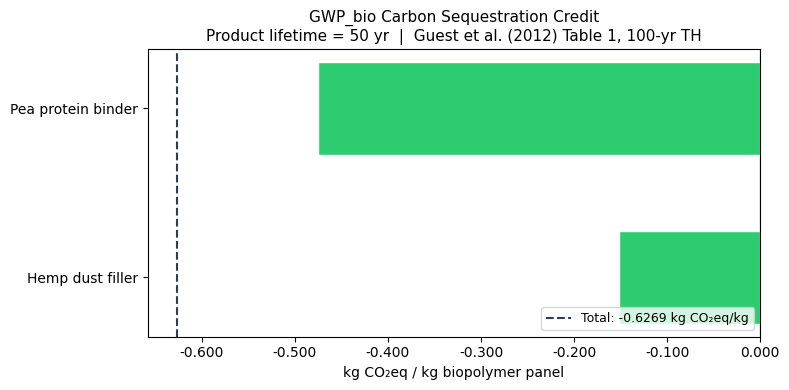

Chart saved to gwpbio_sequestration.png


In [54]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
active = df[df['in_recipe']].copy()
active['short_label'] = active['ingredient'].map(short_labels)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in active['sequestration_kgCO2eq']]
bars = ax.barh(active['short_label'], active['sequestration_kgCO2eq'],
               color=colors, edgecolor='white', height=0.55)

# total line
ax.axvline(total_seq, color='#2c3e50', linewidth=1.5, linestyle='--',
           label=f'Total: {total_seq:+.4f} kg CO₂eq/kg')

# # value labels
# for bar, val in zip(bars, active['sequestration_kgCO2eq']):
#     offset = -0.001 if val < 0 else 0.001
#     ha = 'right' if val < 0 else 'left'
#     ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
#             f'{val:+.4f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('kg CO₂eq / kg biopolymer panel', fontsize=10)
ax.set_title(
    f'GWP_bio Carbon Sequestration Credit\n'
    f'Product lifetime = {PRODUCT_LIFETIME_YR} yr  |  '
    f'Guest et al. (2012) Table 1, 100-yr TH',
    fontsize=11
)
ax.legend(fontsize=9, loc='lower right')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('gwpbio_sequestration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to gwpbio_sequestration.png")
